In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')
 
# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

## 소셜 광고 데이터 셋
[소셜 광고 데이터셋 링크](https://www.kaggle.com/datasets/akram24/social-network-ads?resource=download)

### 소셜 광고 데이터 셋 컬럼
| 컬럼명 (Column) | 데이터 타입 | 설명 (Description) |
| :--- | :--- | :--- |
| **User ID** | 정수형 (Int) | 유저 고유 식별 번호 (학습 시 제외) |
| **Gender** | 문자형 (String) | 유저의 성별 (Male / Female) |
| **Age** | 정수형 (Int) | 유저의 나이 |
| **EstimatedSalary** | 정수형 (Int) | 유저의 추정 연봉 |
| **Purchased** | 정수형 (Int) | 광고 물건 구매 여부 (0: 미구매, 1: 구매)|

In [17]:
import os
import pandas as pd

base_path = "/Users/hyusoohi5/kdt_0900_khs/ml/resource/"
file_name = "social_ads.csv"

file_path = os.path.join(base_path, file_name)

print(file_path)
print(os.path.exists(file_path))

df = pd.read_csv(file_path)
df.head()

/Users/hyusoohi5/kdt_0900_khs/ml/resource/social_ads.csv
True


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


## 1단계, 데이터 전처리

In [3]:
# User ID : 삭제
# 수치형 : Age, EstimatedSalary
# 분류형 : User ID, Gender, Purchased

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          400 non-null    int64
 1   Gender           400 non-null    str  
 2   Age              400 non-null    int64
 3   EstimatedSalary  400 non-null    int64
 4   Purchased        400 non-null    int64
dtypes: int64(4), str(1)
memory usage: 15.8 KB


In [4]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [18]:
ads_df = df.drop("User ID", axis=1)
ads_df.head(3)

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0


In [19]:
ads_df["Purchased"].value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

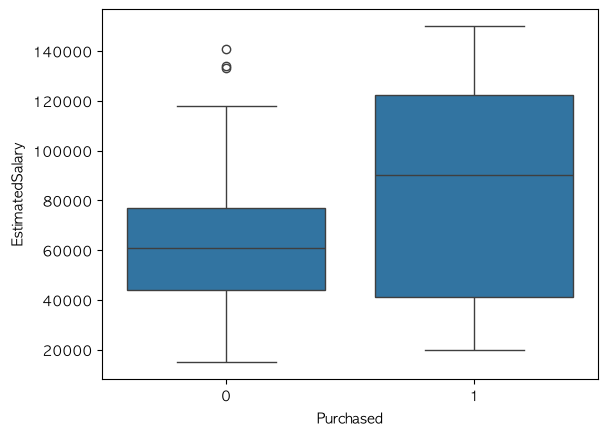

In [7]:
sns.boxplot(ads_df, x="Purchased", y="EstimatedSalary")
plt.show()

In [20]:
ads_df.head(1)

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0


In [21]:
print(ads_df.columns.tolist())

['Gender', 'Age', 'EstimatedSalary', 'Purchased']


In [23]:
X = ads_df.drop("Purchased", axis=1)
X.head()

,Gender,Age,EstimatedSalary
0,Male,19,19000
1,Male,35,20000
2,Female,26,43000
3,Female,27,57000
4,Male,19,76000


### 데이터 누수
- 데이터 셋을 나누고 스케일링을 해야하는 이유 : 데이터 셋을 나누기 전에 전체 데이터를 스케일링하면
-  모델 학습 전에 학습시 절대 보면 안되는 테스트 데이터의 평균과 숫자들이 훈련 데이터셋에 누적되어 누수가 발생한다.

In [24]:
X = ads_df.drop("Purchased", axis=1)
y = ads_df["Purchased"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=2026
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(320, 3) (80, 3) (320,) (80,)


In [29]:
# Gender를 숫자형 더미 변수로 변환
ads_df = pd.get_dummies(
    ads_df,
    columns=["Gender"],
    drop_first=True,
    dtype=int
)

# 입력 데이터와 정답 데이터 분리
X = ads_df.drop("Purchased", axis=1)
y = ads_df["Purchased"]

# 학습용/테스트용 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=2026
)

# X만 표준화
scaler = StandardScaler()
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)

In [30]:
# 2. 모델 준비
# Salary 연봉
X_train_salary = X_train_scaler[:, [1]]
X_test_salary = X_test_scaler[:, [1]]

In [31]:
# 선형 회귀 모델(weight * x) + bias
# weight : 가중치
# bias : 절편
lr = LinearRegression()

In [32]:
lr.fit(X_train_salary, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.18]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.3563
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[17.89]


In [33]:
print(f"선형 모델의 정확도: {lr.score(X_train_salary, y_train)}")

선형 모델의 정확도: 0.1408930349620513


### 결론 쓰레기

In [39]:
print(f"선형 모델의 정확도: {lr.score(X_train_salary, y_train)}")

선형 모델의 정확도: 0.1408930349620513


In [42]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 입력 특성과 정답 분리
X = ads_df.drop("Purchased", axis=1)
y = ads_df["Purchased"]

# 학습용과 테스트용으로 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=2026
)

# 입력 특성만 표준화
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 학습 후 테스트 정확도 확인
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)
print("테스트 정확도:", accuracy_score(y_test, y_pred))

테스트 정확도: 0.7875


## 모델 평가
<img src="https://blog.kakaocdn.net/dna/beQKaR/btsQVxmfALT/AAAAAAAAAAAAAAAAAAAAAEN8Msuz4492U5M2pBZKQ2RtjEOY5OdH6q0btxI5Uurb/img.png?credential=yqXZFxpELC7KVnFOS48ylbz2pIh7yKj8&expires=1790780399&allow_ip=&allow_referer=&signature=7GgzV35irLeFkyH%2BGmsM6uW65LQ%3D" />

## 과적합(overfitting)
- 머신러닝 과적합은 모델이 학습 데이터에만 지나치게 최적화되는 현상을 의미합니다.
- 현재 데이터셋에 지나치게 맞춰지게 되면, 새로운 데이터가 들어왔을 때 예측 능력이 크게 떨어질 수 있습니다.
- 이런 현상이 바로 과적합~!

In [48]:
coef_df = pd.DataFrame({
    "Features": X_train.columns,
    "Coef": lr.coef_[0]
}).sort_values(by="Coef", ascending=False)

coef_df

,Features,Coef
0,Age,2.394875
1,EstimatedSalary,1.161530
2,Gender_Male,0.373889


In [46]:
"""소셜에서 상품을 구매할 때는 연봉보다는 나이가 구매할 때의 영향을 많이 끼친 것으로 파악된다."""

'소셜에서 상품을 구매할 때는 연봉보다는 나이가 구매할 때의 영향을 많이 끼친 것으로 파악된다.'

Text(0.5, 1.0, 'coef_features')

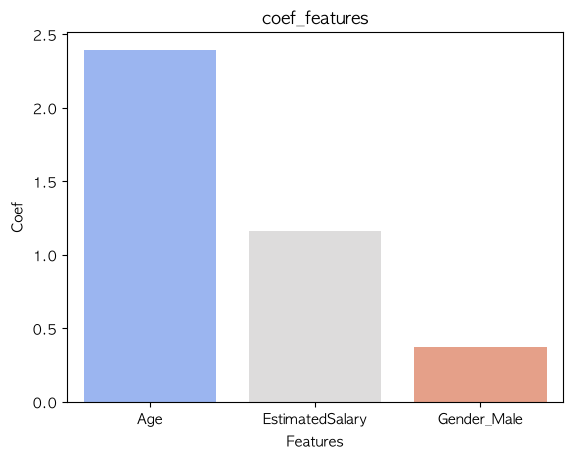

In [53]:
sns.barplot(coef_df, x="Features", y="Coef", hue="Features", palette="coolwarm")
plt.title("coef_features")

Text(0.5, 1.0, 'confusion matrix')

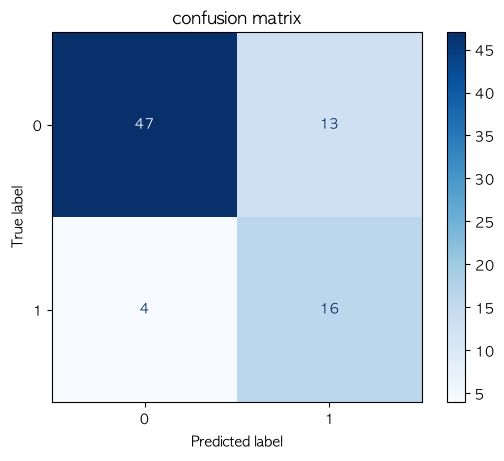

In [51]:
cm = confusion_matrix(y_pred, y_test)
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(cmap="Blues")
plt.title("confusion matrix")